# Research Workflow

This notebook demonstrates the research [workflow](https://langchain-ai.github.io/langgraph/tutorials/workflows/) that creates comprehensive reports through a series of focused steps. The system:

1. Uses a **graph workflow** with specialized nodes for each report creation stage
2. Enables user **feedback and approval** at critical planning points 
3. Produces a well-structured report with introduction, researched body sections, and conclusion

## From repo 

In [1]:
#To start a fresh venv, delete the old one in file explore
#Then use this command: python -m venv .venv
#Then activate it using python interpreter (ctr + shift + P)
#Select the venv path, then open new vs code terminal and you should see the (.venv)

In [2]:
%cd ..
%load_ext autoreload
%autoreload 2

c:\Users\vedan\GitHub\open_deep_research2\src


## From package 

In [3]:
! pip install -U -q open-deep-research

# Compile the Graph-Based Research Workflow

The next step is to compile the LangGraph workflow that orchestrates the report creation process. This defines the sequence of operations and decision points in the research pipeline.

In [4]:
import uuid
import os, getpass
import sys
sys.path.append('/path/to/open_deep_research/src')  # Add the src directory to the path

from IPython.display import Image, display, Markdown
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from legacy.graph import builder  # Import from legacy.graph instead

In [5]:
# Create a memory-based checkpointer and compile the graph
# This enables state persistence and tracking throughout the workflow execution

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

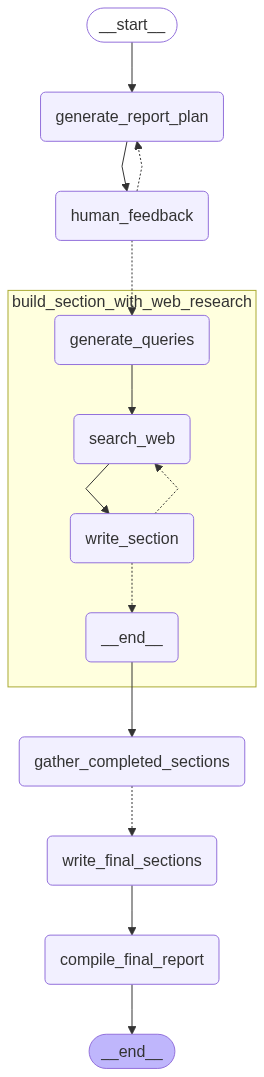

In [6]:
# Visualize the graph structure
# This shows the nodes and edges in the research workflow

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# Helper function to set environment variables for API keys
# This ensures all necessary credentials are available for various services

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")
        
os.environ["OPENAI_API_KEY"] = "" #Also maybe consider switching to gemini pls
os.environ["TAVILY_API_KEY"] = ""

# Set the API keys used for any model or search tool selections below, such as:
#_set_env("OPENAI_API_KEY")
# _set_env("ANTHROPIC_API_KEY")
#_set_env("TAVILY_API_KEY")
# _set_env("GROQ_API_KEY")
# _set_env("PERPLEXITY_API_KEY")

In [ ]:
# Define report structure template and configure the research workflow
# This sets parameters for models, search tools, and report organization

REPORT_STRUCTURE = """Use this structure to create a introduction on the user-provided topic:

You are a research paper summarizer assisting professors when they want to learn
more about a specific field. Your task is to generate a compelling
introduction about the topic that the professor inputs. You are also a top level researcher
in this field. You are extremly specific and detial orientented and that is shown in the
introductions that you write.The introduction should effectively summarize the current state
of research, identify a research gap, and highlight the novelty and contribution of the paper.
Avoid including irrelevant details or overly technical explanations that are not
necessary for an introduction. Use intext MLA citations. 

The introduction should be structured as follows:

1.  **Background:** Begin with a broad overview of the topic the researcher enters and the significance of the research topic.
Explain the existing challenges and the importance of addressing the problem.

2.  **Literature Review and Research Gap:** Summarize relevant previous work in the field. Discuss the limitations of existing approaches
and clearly articulate the research gap that this paper aims to address.

3.  **Contribution and Novelty:** Present the proposed solution and explain how it is innovative and different from previous work.
Clearly state the key contributions of this research and its potential impact.

The introduction should be written in a formal and academic tone, using precise language and technical jargon where appropriate.
It should be concise yet comprehensive, effectively capturing the essence of the paper. For now do not add the third section
(Contribution and Novelty) and inplace of that just put a placeholder. 

Here is an example of a well-written introduction:
***
On 4 July 2019, seismic activity initiated near Ridgecrest, California, and escalated over the next 2 hr
culminating with the occurrence of the first principle mainshock MW 6.4 at 17:33 UTC. It was followed by
an intense aftershock sequence leading up to the occurrence of the second mainshock, MW 7.1 at 03:19
UTC on 6 July 2019. The MW 6.4 and 7.1 mainshocks occurred closely in space (10‐km separation) and
activated a complex fault network composed of conjugate strike‐slip faults including the NW‐trending main
fault with about 65‐km‐long surface rupture and NE‐treading fault with ~15‐km‐long surface rupture
(Barnhart et al., 2019; Goldberg et al., 2019; Kendrick et al., 2019; Liu et al., 2019; Ross et al., 2019;
Figure 1). A high‐precision near real‐time catalog enables us to rapidly characterize the earthquake sequence
(Stewart, 1977), such as tracking seismicity evolution (Peng & Zhao, 2009; Ross et al., 2017; Zhang & Wen,
2015a) and identification of causative faults (Kao & Shan, 2007; Yang et al., 2009). The challenge is to build
a high‐precision earthquake catalog in near real‐time when the event rate becomes extreme.
Earthquake catalog building strongly depends on earthquake detection and location techniques. Two main
classes of methods are widely used in earthquake detection and location: pick‐based methods and
waveform‐based methods (Grigoli et al., 2018; Pesicek et al., 2014; Stewart, 1977; Zhang et al., 2019).
Independent of seismic phase picking, waveform‐based methods detect, associate, and locate earthquakes
simultaneously in a single step based on the delay‐and‐sum concept (Kao & Shan, 2004; Peng & Zhao,
2009; Shelly et al., 2007; Zhang & Wen, 2015b). They are sensitive to small earthquakes by maximizing
seismic energy or coherence but suffer from high computational costs due to their exhaustive searching in
space and time. Consequently, pick‐based methods are still the preferred solution for routine earthquake
monitoring due to their high computational efficiency (Grigoli et al., 2018). Seismic picks are conventionally
obtained from handpicking or automatic picking algorithms such as the short‐term average/long‐term
average picker (Allen, 1978; Withers et al., 1998). Recently, machine‐learning techniques have been
widely adopted in seismic phase picking, showing promise in both picking efficiency and picking accuracy
(e.g., Ross et al., 2018; Wang et al., 2019; Zhu et al., 2019; Zhu & Beroza, 2019). A high‐precision earthquake
catalog provides a window into the details of seismic fault structures. Various
techniques have been widely used to investigate fault structures after earthquakes occurred but hampered by
different aspects, such as: Focal mechanism inversion methods are only eligible to reveal the major fault
plane (e.g., Gephart & Forsyth, 1984); geodetic observations have little depth resolution (e.g., Ward &
Valensise, 1989); and on‐site surveys are not able to investigate buried faults (e.g., Xu et al., 2009).
Earthquakes may be accommodated on known or newly activated faults (Ross et al., 2019; Waldhauser,2009; Waldhauser & Ellsworth, 2002).
Thus, accurate earthquake locations play an important role in deli-neation of detailed seismic fault structures.
In this study, we first build sequential earthquake catalogs for the 2019 Ridgecrest earthquake sequence
from continuous waveform data using a machine‐learning picker, a newly developed earthquake association
and location algorithm, and two other high‐precision location programs. Then we compare our catalogs with
other available catalogs. Our results clearly reveal the seismicity migration in space and time and character-
ize seismic fault structures activated during the earthquake sequence.
***"""

# # Configuration option 1: Claude 3.7 Sonnet for planning with perplexity search
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "perplexity",
#                            "planner_provider": "anthropic",
#                            "planner_model": "claude-3-7-sonnet-latest",
#                            # "planner_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "writer_provider": "anthropic",
#                            "writer_model": "claude-3-5-sonnet-latest",
#                            # "writer_model_kwargs": {"temperature":0.8}, # if set custom parameters
#                            "max_search_depth": 2,
#                            "report_structure": REPORT_STRUCTURE,
#                            }}

# # Configuration option 2: DeepSeek-R1-Distill-Llama-70B for planning and llama-3.3-70b-versatile for writing
# thread = {"configurable": {"thread_id": str(uuid.uuid4()),
#                            "search_api": "tavily",
#                            "planner_provider": "groq",
#                            "planner_model": "deepseek-r1-distill-llama-70b",
#                            "writer_provider": "groq",
#                            "writer_model": "llama-3.3-70b-versatile",
#                            "report_structure": REPORT_STRUCTURE,
#                            "max_search_depth": 1,}
#                            }

# Configuration option 3: Use OpenAI o3 for both planning and writing (selected option)
thread = {"configurable": {"thread_id": str(uuid.uuid4()),
                           "search_api": "tavily",
                           "planner_provider": "openai",
                           "planner_model": "gpt-4o-mini",
                           "writer_provider": "openai",
                           "writer_model": "gpt-4o-mini",
                           "max_search_depth": 2,
                           "report_structure": REPORT_STRUCTURE,
                           }} 

# Define research topic about Model Context Protocol
topic = "Explore mars' shallow and deep interiors using seismic data and write a full length research paper about this topic."
# Run the graph workflow until first interruption (waiting for user feedback)
async for event in graph.astream({"topic":topic,}, thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: An overview of the current state of research on Mars' shallow and deep interiors using seismic data collected by the InSight mission, highlighting the significance of understanding Mars’ internal structure.
Research needed: No


Section: Seismic Data Collection and Techniques
Description: This section discusses the methodologies and instruments used by the InSight mission for collecting seismic data, including the Seismic Experiment for Interior Structure (SEIS) and the significance of different seismic wave types.
Research needed: Yes


Section: The Shallow Interior of Mars
Description: An in-depth analysis of the shallow Martian subsurface, examining findings regarding the crust's structure, material layers, and the implications of seismic wave propagation on its geological history.
Research needed: Yes


Section: The Deep Interior of Mars
Description: An exploration of Mars' deep interior, focusing on findings regarding the mantle and core, including seismic discontinuities and mineral phase transitions, based on data from InSight.
Research needed: Yes


Section: Comparison of Martian and Terrestrial Seismic Activity
Description: A comparative analysis of seismic activity on Mars versus Earth, exploring the implications for planetary formation and tectonic structures based on InSight data.
Research needed: Yes


Section: Research Gaps and Future Directions
Description: Identification of current limitations in Mars seismology and proposals for future research avenues that could address unanswered questions about Mars' internal structure.
Research needed: Yes


Section: Conclusion
Description: A summary of the key findings from the report and their implications for understanding Mars' geological history and potential for past or present life.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# User Feedback Phase

* This allows for providing directed feedback on the initial report plan
* The user can review the proposed report structure and provide specific guidance
* The system will incorporate this feedback into the final report plan

In [10]:
# Submit feedback on the report plan
# The system will continue execution with the updated requirements

# Provide specific feedback to focus and refine the report structure
async for event in graph.astream(Command(resume="Please combine all the sections related to the Literature review section of the introduction as outlined in the prompt. "), thread, stream_mode="updates"):
    if '__interrupt__' in event:
        interrupt_value = event['__interrupt__'][0].value
        display(Markdown(interrupt_value))

Please provide feedback on the following report plan. 
                        

Section: Introduction
Description: An overview of the current state of research on Mars' shallow and deep interiors, establishing the significance of the topic.
Research needed: No


Section: Mars Seismology Overview
Description: Exploration of how seismic data has been used to study Mars' internal structure, specifically focusing on the InSight mission and its contributions to our understanding of Mars' crust, mantle, and core.
Research needed: Yes


Section: Shallow Interior Structures
Description: A detailed analysis of the shallow crustal structures of Mars, including findings related to sedimentary layers, seismic low-velocity zones, and other geological features.
Research needed: Yes


Section: Deep Interior Structures
Description: Examination of the seismic data revealing insights into the composition and characteristics of Mars' deep interior, including the core-mantle boundary and core composition.
Research needed: Yes


Section: Comparative Findings with Earth
Description: A review of how the findings from Mars seismology compare with our understanding of Earth's interior, emphasizing differences and similarities in internal structures.
Research needed: Yes


Section: Conclusion
Description: Summary of the research findings, implications for future studies, and the potential impact of better understanding Mars' interiors on planetary science.
Research needed: No


                        
Does the report plan meet your needs?
Pass 'true' to approve the report plan.
Or, provide feedback to regenerate the report plan:

# Final Approval Phase
* After incorporating feedback, approve the plan to start content generation

In [11]:
# Approve the final plan and execute the report generation
# This triggers the research and writing phases for all sections

# The system will now:
# 1. Research each section topic
# 2. Generate content with citations
# 3. Create introduction and conclusion
# 4. Compile the final report

async for event in graph.astream(Command(resume=True), thread, stream_mode="updates"):
    print(event)
    print("\n")

{'human_feedback': None}


{'build_section_with_web_research': {'completed_sections': [Section(name='Deep Interior Structures', description="Examination of the seismic data revealing insights into the composition and characteristics of Mars' deep interior, including the core-mantle boundary and core composition.", research=True, content="## Deep Interior Structures\n\nRecent seismic studies of Mars have provided significant insights into the planet’s deep interior, particularly concerning its core and the core-mantle boundary. Seismic data from low-frequency marsquakes indicate that Mars possesses a large, liquid core with a radius estimated between approximately 1620 to 1870 kilometers, hence making it roughly half the size of Earth's core[1][6]. This core is likely composed of an iron-nickel alloy enriched with light elements like sulfur, oxygen, and carbon, estimated to be around 20 to 22 wt% of these lighter elements[2][4].\n\nMoreover, analysis of seismic wave patterns has identif

In [12]:
# Display the final generated report
# Retrieve the completed report from the graph's state and format it for display

final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)

# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

Understanding Mars' interior is crucial for unraveling its geological history and evolution. The InSight mission has laid the foundation for this exploration, employing seismic data to reveal significant insights about the planet's shallow and deep structures. Key findings indicate a thinner crust, a complex mantle, and a liquid core composed of lighter elements. By examining the shallow layers, researchers have identified sedimentary formations and low-velocity zones, shedding light on Mars' geological processes. This report synthesizes findings from the InSight mission to illuminate Mars’ internal composition and compare its geophysical properties to those of Earth, providing a comprehensive overview of our current understanding of the Martian interior.

## Mars Seismology Overview

The InSight mission has significantly advanced our understanding of Mars' internal structure through seismic data collection. Launched in May 2018, InSight deployed the Seismic Experiment for Interior Structure (SEIS), which has recorded over 1,300 marsquakes, enabling detailed analysis of the planet's crust, mantle, and core. The mission revealed that Mars' crust is thinner than expected, averaging around 20 to 37 kilometers thick with possible sub-layers. This structure suggests a more complex geological history akin to Earth's crust, characterized by layering processes reflecting terrestrial formation dynamics [3][5][7].

Beneath the crust lies the mantle, extending approximately 1,560 kilometers, while the core measures about 1,830 kilometers in radius. InSight's findings confirm that Mars has a molten core, a crucial aspect for understanding the planet's thermal and magnetic history [1][9]. Moreover, the seismic waves captured during marsquakes have provided insights into the core's density and composition, indicating the presence of lighter elements within the core, which influences theories of planetary formation [8][9]. This mission has established a foundation for interpreting seismic data that continues to unveil the mysteries of Mars' formation and geologic evolution.

### Sources
[1] Crust, mantle and core structure of Mars from InSight seismic data - URL: https://ui.adsabs.harvard.edu/abs/2021EPSC...15..512K/abstract  
[2] Upper mantle structure of Mars from InSight seismic data - Science - URL: https://www.science.org/doi/10.1126/science.abf2966  
[3] NASA's InSight Reveals the Deep Interior of Mars - URL: https://www.jpl.nasa.gov/news/nasas-insight-reveals-the-deep-interior-of-mars/  
[4] How InSight Revealed the Heart of Mars - Teachable Moment - URL: https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/  
[5] InSight (Interior Exploration using Seismic Investigations, Geodesy ...) - URL: https://www.mps.mpg.de/planetary-science/insight-mission  
[6] InSight (Interior Exploration using Seismic Investigations, Geodesy ...) - URL: https://www.eoportal.org/satellite-missions/insight  
[7] NASA's InSight Reveals the Deep Interior of Mars - URL: https://www.nasa.gov/centers-and-facilities/jpl/nasas-insight-reveals-the-deep-interior-of-mars/  
[8] InSight | ETH Zurich on Mars - URL: https://www.insight.ethz.ch/en/home/  
[9] NASA's InSight Reveals the Deep Interior of Mars - URL: https://www.nasa.gov/centers-and-facilities/jpl/nasas-insight-reveals-the-deep-interior-of-mars/

## Shallow Interior Structures

Recent studies of Mars' shallow crustal structures reveal significant geological features linked to sedimentary formations and seismic low-velocity zones. The InSight mission's seismic data analysis has identified a low-velocity zone situated between 30 to 75 meters beneath the Martian surface. This zone is interpreted as a sedimentary layer interspersed amid older basalt layers from the Hesperian and Amazonian periods, indicating a complex sedimentary history in this region of Elysium Planitia[^1][^7].

Detailed seismic tomography has shown that the Martian crust consists of a layered structure with a thin regolith atop extensive basalt flows, largely confirming earlier models[^2][^6]. Additionally, the ambient seismic field predominantly contains Rayleigh waves, which are sensitive to the subsurface layering, allowing researchers to interpret the local geological history more effectively[^1][^2].

The seismic characteristics observed also suggest a distinct amplitude peak at 2.4 Hz, likely related to surface wave energy trapped within the low-velocity sedimentary channel, further emphasizing the intricate dynamics of Mars' shallow geological framework[^1][^5][^7]. These findings enhance our understanding of the geological processes, including sedimentation and volcanism, that have shaped Mars over its history.

### Sources
[1] The shallow structure of Mars at the InSight landing site from inversion of ambient vibrations - Nature Communications: https://www.nature.com/articles/s41467-021-26957-7  
[2] Thickness and structure of the Martian crust from InSight seismic data - Science: https://www.science.org/doi/10.1126/science.abf8966  
[5] Structure of the Martian Crust Below InSight From Surface Waves - AGU Publications: https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2023GL104601  
[6] Upper Mantle Low Velocity Zones of Mars Revealed by Receiver Functions - LPSC: https://www.hou.usra.edu/meetings/lpsc2024/pdf/1391.pdf  
[7] Uncovering Shallow Crustal Structures of Mars Beneath the InSight - AGU Publications: https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2024JE008927?af=R  

## Deep Interior Structures

Recent seismic studies of Mars have provided significant insights into the planet’s deep interior, particularly concerning its core and the core-mantle boundary. Seismic data from low-frequency marsquakes indicate that Mars possesses a large, liquid core with a radius estimated between approximately 1620 to 1870 kilometers, hence making it roughly half the size of Earth's core[1][6]. This core is likely composed of an iron-nickel alloy enriched with light elements like sulfur, oxygen, and carbon, estimated to be around 20 to 22 wt% of these lighter elements[2][4].

Moreover, analysis of seismic wave patterns has identified the core-mantle boundary as a region of significant interest. The studies suggest that complex crystallization processes may occur within the core. The presence of iron “snow” formation and possibly a stratified liquid outer core could have major implications for our understanding of Martian geodynamics and the historical absence of a magnetic field, suggesting that convection within the core may have ceased over time due to cooling processes[3][4]. The implications of these findings illustrate the core's critical role in influencing Mars' geological history.

### Sources
[1] Seismic detection of the martian core: https://www.ipgp.fr/~stutz/2021_stahler_al_insight_core_science.pdf  
[2] First observations of core-transiting seismic phases on Mars - PNAS: https://www.pnas.org/doi/10.1073/pnas.2217090120  
[3] Seismic detection of the martian core - Science: https://www.science.org/doi/10.1126/science.abi7730  
[4] Mars core structure—concise review and anticipated insights from InSight: https://progearthplanetsci.springeropen.com/articles/10.1186/s40645-017-0139-4  
[5] An analysis of direct, reflected, and converted seismic body waves: https://www.sciencedirect.com/science/article/pii/S0031920122000127  
[6] Core formation and geophysical properties of Mars: https://www.sciencedirect.com/science/article/abs/pii/S0012821X19306156

## Comparative Findings with Earth

Recent findings from Mars' seismic data reveal significant differences and a few intriguing similarities between the internal structures of Mars and Earth. For instance, both planets exhibit a layered structure comprising a crust, mantle, and core. Mars' crust, however, is thinner than Earth's, with a depth of approximately 12 to 23 miles, compared to Earth's varying crustal thickness ranging from 0 to 30 miles depending on the region [6][8].

A profound difference lies in their cores; Mars is confirmed to have a completely liquid core predominantly composed of iron and sulfide, contrasting with Earth's liquid outer core and solid inner core [5][8]. The radius of Mars' core is about 1,137 miles, making it less dense compared to Earth's core, which suggests differing formative conditions [6][9]. Seismic waves provide insights into these variances; they travel differently through materials, revealing the physical and chemical composition of the layers they traverse [7][10].

Interestingly, Mars has no tectonic plates, unlike Earth, leading to marsquakes caused by shrinking crust and fault formation rather than plate movement [5][8]. These differences underscore the distinct geological histories and evolutions of the two planets, while also enriching our understanding of terrestrial planet formation. 

### Sources
[1] Study details differences between deep interiors of Mars and Earth: https://www.reuters.com/technology/space/study-details-differences-between-deep-interiors-mars-earth-2023-04-25/  
[2] First observations of core-transiting seismic phases on Mars - PNAS: https://www.pnas.org/doi/10.1073/pnas.2217090120  
[3] Thickness and structure of the martian crust from InSight seismic data: https://www.science.org/doi/10.1126/science.abf8966  
[4] How InSight Revealed the Heart of Mars – Teachable Moment: https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-insight-revealed-the-heart-of-mars/  
[5] NASA's InSight Reveals the Deep Interior of Mars: https://www.nasa.gov/centers-and-facilities/jpl/nasas-insight-reveals-the-deep-interior-of-mars/  
[6] Mars vs Earth—General physical comparison - IRIS: https://www.iris.edu/hq/inclass/animation/mars_vs_earth  
[7] Can seismic waves tell us about the formation of terrestrial planets?: https://www.openaccessgovernment.org/seismic-waves-formation-terrestrial-planets-earth-mars/158402/  
[8] Scientists Detect Seismic Waves Traveling Through Martian Core for the First Time: https://cmns.umd.edu/news-events/news/scientists-detect-seismic-waves-traveling-through-martian-core-first-time  
[9] Mars core structure—concise review and anticipated insights from...: https://progearthplanetsci.springeropen.com/articles/10.1186/s40645-017-0139-4  
[10] Mars vs Earth: Key Difference Explained - PlayShifu: https://www.playshifu.com/blog/mars-vs-earth-key-difference-explained  


# Exploring Mars' Shallow and Deep Interiors Using Seismic Data

Understanding Mars' internal structure is crucial for unraveling the planet's geological history and potential habitability. The InSight mission has provided a wealth of seismic data, revealing the complexities of Mars' crust, mantle, and core. Key findings include a thinner-than-expected crust, a significant low-velocity sedimentary layer in the shallow structures, and insights into the core's composition and dynamics. This report synthesizes these findings, comparing them with Earth's internal structures, to enhance our understanding of planetary formation and evolution, highlighting the profound implications for future studies in planetary science.

## Conclusion

The insights gained from Mars' seismic investigations significantly deepen our understanding of its internal geology. The InSight mission has confirmed a layered crust, revealing complexities such as sedimentary formations and low-velocity zones. Seismic data also indicates Mars' liquid core composition and its core-mantle boundary's unique characteristics. Comparative analysis with Earth shows both distinct differences—such as the absence of tectonic plates and a fully liquid core—and notable similarities in layered structures. 

| Feature                    | Mars                                  | Earth                                 |
|----------------------------|---------------------------------------|---------------------------------------|
| Crust Thickness             | 20-37 km                             | Up to 50 km                           |
| Core State                  | Liquid core                          | Liquid outer core, solid inner core   |
| Key Composition             | Iron-nickel alloy with lighter elements | Iron-nickel alloy                      |
| Tectonic Activity           | None (shrinking crust)               | Present (plate tectonics)             |

These revelations underscore the need for continuous exploration, as better understanding Mars' interiors not only informs planetary science but also the broader context of planetary evolution and dynamics across the solar system. Future studies should focus on refining seismic models and expanding our knowledge of other planetary bodies through comparative planetology.

In [13]:
import os
import re # Import regular expression module
from IPython.display import FileLink, display

# Define the base filename for your report
base_report_filename = "generated_research_report"
file_extension = ".md"

# Define the directory to save the report (e.g., current directory)
output_directory = os.getcwd()
output_directory += "\legacy\\reports"

# --- Find the next available edition number ---
next_edition_number = 1
existing_reports = []

# List all files in the output directory
try:
    for filename in os.listdir(output_directory):
        # Check if the filename matches our pattern (e.g., generated_research_report_X.md)
        match = re.match(rf"^{re.escape(base_report_filename)}_(\d+){re.escape(file_extension)}$", filename)
        if match:
            # Extract the number and add it to our list
            existing_reports.append(int(match.group(1)))

    if existing_reports:
        # If reports exist, the next edition is the highest existing number + 1
        next_edition_number = max(existing_reports) + 1

except FileNotFoundError:
    print(f"Directory not found: {output_directory}. Assuming first report.")
except Exception as e:
    print(f"Error while checking existing reports: {e}. Starting with edition 1.")

# Construct the new filename with the edition number
report_filename = f"{base_report_filename}_{next_edition_number}{file_extension}"
output_filepath = os.path.join(output_directory, report_filename)

print(f"Attempting to save report as: {report_filename} to: {output_filepath}")

try:
    with open(output_filepath, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"Report saved successfully to: {output_filepath}")

    # Verify if the file actually exists after writing
    if os.path.exists(output_filepath):
        print(f"Confirmation: File exists at {output_filepath}")
        # Create a download link - use the relative path for FileLink
        display(FileLink(report_filename))
    else:
        print(f"ERROR: File was NOT found at {output_filepath} immediately after writing.")

except PermissionError:
    print(f"ERROR: Permission denied. Cannot write to {output_filepath}.")
    print("Please check write permissions for this directory.")
except Exception as e:
    print(f"An unexpected error occurred while saving the report: {e}")


Attempting to save report as: generated_research_report_3.md to: c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_3.md
Report saved successfully to: c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_3.md
Confirmation: File exists at c:\Users\vedan\GitHub\open_deep_research2\src\legacy\reports\generated_research_report_3.md


c:\Users\vedan\GitHub\open_deep_research2\src\generated_research_report_3.md